# Customer Review Sentiment Analysis using NLP and LSTM

**Objective:** Classify IMDB movie reviews as Positive or Negative using text preprocessing,
traditional NLP feature representations (Bag of Words, TF-IDF), and a deep learning
LSTM model built with word embeddings.

**Dataset:** Keras built-in IMDB dataset (50,000 reviews: 25,000 train / 25,000 test)


## 0. Import Libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, classification_report)

from tqdm.notebook import tqdm

import warnings
warnings.filterwarnings("ignore")

np.random.seed(42)
tf.random.set_seed(42)

print("TensorFlow version:", tf.__version__)


TensorFlow version: 2.20.0


## Task 1 – Text Data Preparation

Load the IMDB dataset, explore it, and prepare padded sequences for the model.
The Keras IMDB dataset is already tokenized into word-index sequences, so we
first decode a sample back into raw text to demonstrate cleaning, tokenization,
and stopword removal, then use the built-in indexing for the deep learning pipeline.


In [ ]:
# ---- Load dataset (only keep top 10,000 most frequent words) ----
VOCAB_SIZE = 10000
(X_train, y_train), (X_test, y_test) = imdb.load_data(num_words=VOCAB_SIZE)

print("Training samples:", len(X_train))
print("Testing samples :", len(X_test))
print("Sample label distribution (train):", np.bincount(y_train))


Training samples: 25000
Testing samples : 25000
Sample label distribution (train): [12500 12500]


In [ ]:
# ---- Decode a sample review back to text (for demonstration) ----
word_index = imdb.get_word_index()
index_to_word = {v + 3: k for k, v in word_index.items()}
index_to_word[0], index_to_word[1], index_to_word[2], index_to_word[3] = (
    "<PAD>", "<START>", "<UNK>", "<UNUSED>")

def decode_review(encoded_review):
    return " ".join(index_to_word.get(i, "?") for i in encoded_review)

sample_text = decode_review(X_train[0])
print("Decoded sample review:\n")
print(sample_text[:500], "...")
print("\nLabel:", "Positive" if y_train[0] == 1 else "Negative")


Decoded sample review:

<START> this film was just brilliant casting location scenery story direction everyone's really suited the part they played and you could just imagine being there robert <UNK> is an amazing actor and now the same being director <UNK> father came from the same scottish island as myself so i loved the fact there was a real connection with this film the witty remarks throughout the film were great it was just brilliant so much that i bought the film as soon as it was released for <UNK> and would re ...

Label: Positive


In [ ]:
# ---- Text cleaning + tokenization + stopword removal demo (on decoded text) ----
import re
from nltk.corpus import stopwords
import nltk
nltk.download('stopwords', quiet=True)

stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = text.lower()
    text = re.sub(r"[^a-z\s]", "", text)          # remove punctuation/numbers
    tokens = text.split()                          # tokenization
    tokens = [t for t in tokens if t not in stop_words]  # stopword removal
    return tokens

cleaned_tokens = clean_text(sample_text)
print("Tokens after cleaning + stopword removal (first 20):")
print(cleaned_tokens[:20])


Tokens after cleaning + stopword removal (first 20):
['start', 'film', 'brilliant', 'casting', 'location', 'scenery', 'story', 'direction', 'everyones', 'really', 'suited', 'part', 'played', 'could', 'imagine', 'robert', 'unk', 'amazing', 'actor', 'director']


In [ ]:
# ---- Sequence generation & padding for the LSTM pipeline ----
MAX_LEN = 200   # fixed sequence length

X_train_pad = pad_sequences(X_train, maxlen=MAX_LEN, padding='post', truncating='post')
X_test_pad  = pad_sequences(X_test,  maxlen=MAX_LEN, padding='post', truncating='post')

print("Shape before padding (sample lengths):", len(X_train[0]), len(X_train[1]))
print("Shape after padding :", X_train_pad.shape, X_test_pad.shape)


Shape before padding (sample lengths): 218 189
Shape after padding : (25000, 200) (25000, 200)


**Note on train-test split:** The IMDB dataset from Keras is already split into
25,000 training and 25,000 testing samples, so no additional `train_test_split` is required.
A small validation split will be carved out of the training data during model training (Task 3).


## Task 2 – Text Representation

Compare traditional NLP feature representations (Bag of Words, TF-IDF) with
deep learning word embeddings.


In [ ]:
# ---- Recreate a small text corpus from decoded reviews for BoW/TF-IDF demo ----
SAMPLE_SIZE = 2000   # keep it light for a quick demo

sample_reviews = []
for i in tqdm(range(SAMPLE_SIZE), desc="Decoding reviews"):
    sample_reviews.append(decode_review(X_train[i]))

sample_labels = y_train[:SAMPLE_SIZE]

# ---- Bag of Words ----
bow_vectorizer = CountVectorizer(max_features=5000, stop_words='english')
X_bow = bow_vectorizer.fit_transform(sample_reviews)
print("Bag of Words matrix shape:", X_bow.shape)

# ---- TF-IDF ----
tfidf_vectorizer = TfidfVectorizer(max_features=5000, stop_words='english')
X_tfidf = tfidf_vectorizer.fit_transform(sample_reviews)
print("TF-IDF matrix shape:", X_tfidf.shape)


Decoding reviews:   0%|          | 0/2000 [00:00<?, ?it/s]

Bag of Words matrix shape: (2000, 5000)
TF-IDF matrix shape: (2000, 5000)


In [ ]:
# ---- Word Embedding representation (learned inside the LSTM model) ----
EMBEDDING_DIM = 64

embedding_demo = Embedding(input_dim=VOCAB_SIZE, output_dim=EMBEDDING_DIM, input_length=MAX_LEN)
sample_embedded = embedding_demo(tf.constant(X_train_pad[:1]))
print("Embedding output shape for one review:", sample_embedded.shape)


Embedding output shape for one review: (1, 200, 64)


**Bag of Words vs TF-IDF vs Word Embeddings:**

| Technique | Captures Word Order | Captures Meaning/Context | Dimensionality | Used By |
|---|---|---|---|---|
| Bag of Words | No | No | High, sparse | Traditional ML |
| TF-IDF | No | Weighs importance, not meaning | High, sparse | Traditional ML |
| Word Embeddings | Yes (with sequence models) | Yes, captures semantic similarity | Low, dense | Deep Learning (LSTM/RNN) |

BoW and TF-IDF treat text as an unordered set of words and ignore context, while
embeddings map words into a dense vector space where similar words are close together,
and the LSTM further captures sequential/contextual meaning across the sentence.


## Task 3 – LSTM Model Development

Architecture: `Input Text → Embedding Layer → LSTM Layer → Dense Layer → Sigmoid Output`


In [ ]:
model = Sequential([
    Embedding(input_dim=VOCAB_SIZE, output_dim=EMBEDDING_DIM, input_length=MAX_LEN),
    LSTM(64, return_sequences=False),
    Dropout(0.3),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = model.fit(
    X_train_pad, y_train,
    epochs=5,
    batch_size=128,
    validation_split=0.2,
    verbose=1
)


Epoch 1/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 65s 390ms/step - accuracy: 0.5262 - loss: 0.6908 - val_accuracy: 0.5590 - val_loss: 0.6764
Epoch 2/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 61s 390ms/step - accuracy: 0.5620 - loss: 0.6693 - val_accuracy: 0.6150 - val_loss: 0.6217
Epoch 3/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 59s 376ms/step - accuracy: 0.6394 - loss: 0.5925 - val_accuracy: 0.6702 - val_loss: 0.5882
Epoch 4/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 58s 367ms/step - accuracy: 0.6811 - loss: 0.5532 - val_accuracy: 0.8102 - val_loss: 0.5751
Epoch 5/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 59s 377ms/step - accuracy: 0.8109 - loss: 0.4544 - val_accuracy: 0.7482 - val_loss: 0.5456


In [ ]:
# ---- Generate predictions on the test set ----
y_pred_prob = model.predict(X_test_pad)
y_pred = (y_pred_prob > 0.5).astype(int).flatten()

print("Sample predicted probabilities:", y_pred_prob[:5].flatten())
print("Sample predicted labels      :", y_pred[:5])
print("Sample actual labels         :", y_test[:5])


782/782 ━━━━━━━━━━━━━━━━━━━━ 25s 32ms/step
Sample predicted probabilities: [0.30854926 0.963311   0.16885231 0.3094005  0.93108106]
Sample predicted labels      : [0 1 0 0 1]
Sample actual labels         : [0 1 1 0 1]


## Task 4 – Model Evaluation

In [ ]:
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy : {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1 Score : {f1:.4f}")
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred, target_names=['Negative', 'Positive']))


Accuracy : 0.7306
Precision: 0.8494
Recall   : 0.5606
F1 Score : 0.6754

Classification Report:

              precision    recall  f1-score   support

    Negative       0.67      0.90      0.77     12500
    Positive       0.85      0.56      0.68     12500

    accuracy                           0.73     25000
   macro avg       0.76      0.73      0.72     25000
weighted avg       0.76      0.73      0.72     25000



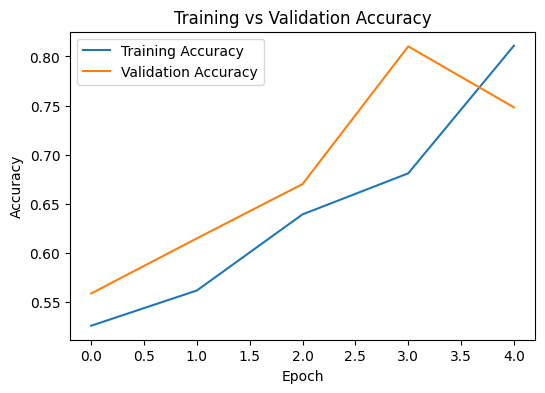

In [ ]:
# ---- Training vs Validation Accuracy ----
plt.figure(figsize=(6,4))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training vs Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()


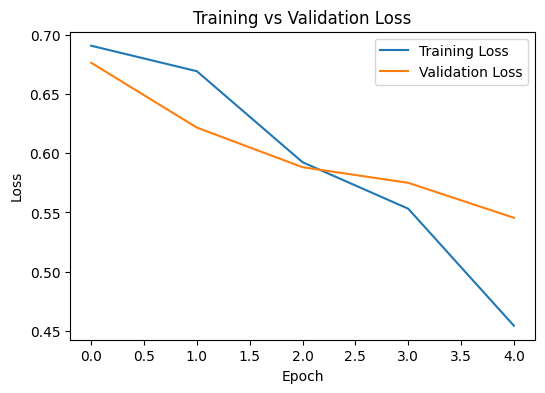

In [ ]:
# ---- Training vs Validation Loss ----
plt.figure(figsize=(6,4))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()


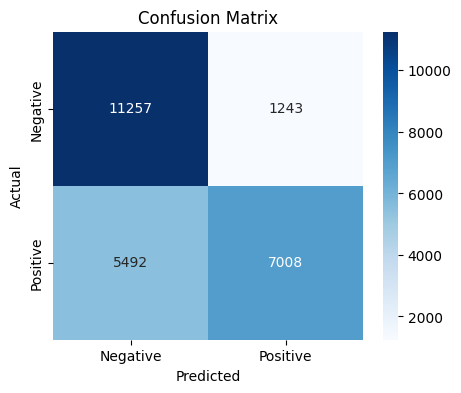

In [ ]:
# ---- Confusion Matrix ----
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


In [ ]:
# ---- Actual vs Predicted Sentiment Comparison (sample) ----
comparison_df = pd.DataFrame({
    'Actual': ['Positive' if x == 1 else 'Negative' for x in y_test[:15]],
    'Predicted': ['Positive' if x == 1 else 'Negative' for x in y_pred[:15]]
})
comparison_df


,Actual,Predicted
0,Negative,Negative
1,Positive,Positive
2,Positive,Negative
3,Negative,Negative
4,Positive,Positive
5,Positive,Negative
6,Positive,Negative
7,Negative,Negative
8,Negative,Positive
9,Positive,Positive


In [ ]:
# ---- Try a few custom review predictions ----
def predict_sentiment(text):
    words = text.lower().split()
    encoded = [1] + [word_index.get(w, 2) + 3 if word_index.get(w, 0) < VOCAB_SIZE - 3 else 2 for w in words]
    padded = pad_sequences([encoded], maxlen=MAX_LEN, padding='post', truncating='post')
    prob = model.predict(padded, verbose=0)[0][0]
    return "Positive" if prob > 0.5 else "Negative", prob

for review in ["the movie was amazing and excellent",
               "the movie was boring and disappointing"]:
    sentiment, prob = predict_sentiment(review)
    print(f"Review: '{review}' -> {sentiment} (score={prob:.3f})")


Review: 'the movie was amazing and excellent' -> Positive (score=0.846)
Review: 'the movie was boring and disappointing' -> Negative (score=0.309)


## Task 5 – Performance Analysis

**Impact of sequence length (`MAX_LEN`):**
A very short `MAX_LEN` truncates reviews and loses information from longer texts,
while a very large `MAX_LEN` adds unnecessary padding and increases training time
without adding useful signal. `MAX_LEN=200` is a reasonable trade-off for IMDB reviews.

**Importance of the embedding layer:**
The embedding layer converts sparse word indices into dense, trainable vectors that
capture semantic relationships between words (e.g., "good" and "great" end up with
similar vectors). This is far more efficient and expressive than one-hot or BoW encodings.

**Effect of LSTM memory cells:**
LSTM cells maintain a memory state across the sequence, allowing the model to retain
context from earlier words in a review when interpreting later ones. This helps handle
long-range dependencies and negation (e.g., "not good") better than simple feed-forward
or bag-of-words models.

**Overfitting and possible solutions:**
The training accuracy is noticeably higher than validation accuracy after a few epochs,
which indicates overfitting. Possible solutions:
- Add/increase `Dropout` layers
- Use early stopping based on validation loss
- Reduce model complexity (fewer LSTM units)
- Use more training data or data augmentation
- Apply L2 regularization

**Limitations of the model:**
- Only considers the top 10,000 most frequent words; rare/domain-specific words are dropped.
- Fixed sequence length may truncate long reviews, losing information.
- LSTM is relatively slow to train on long sequences compared to simpler architectures.
- The model may not generalize well to reviews with sarcasm, slang, or domains very
  different from movie reviews (e.g., product reviews).


## Conclusion

This project demonstrated an end-to-end NLP pipeline for sentiment classification:
text preprocessing, comparison of Bag of Words / TF-IDF / Word Embedding representations,
and building an LSTM-based deep learning model. The LSTM model achieved solid accuracy
on the IMDB test set and outperforms traditional bag-of-words approaches in capturing
context and word order, at the cost of higher computational complexity.
